Im aktuellen Verzeichnis wurde ein Unterodner Analysis_Scan7639_LCORR erstellt, in dem die Abbildungen der Auswertung zu finden sind!
Auswertung fertig!


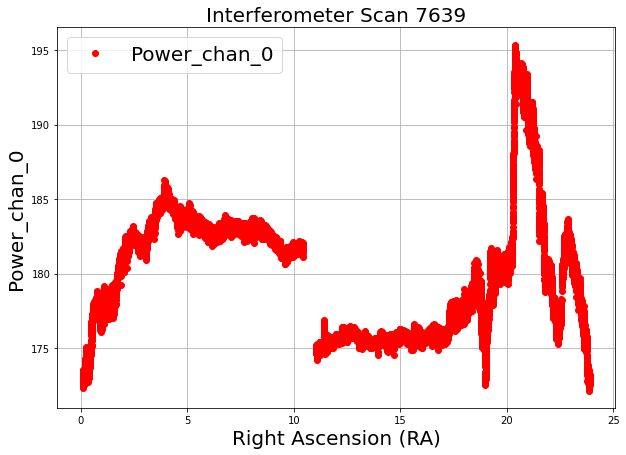

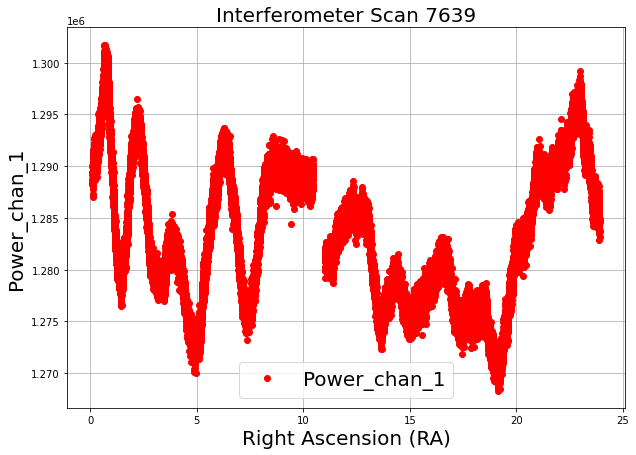

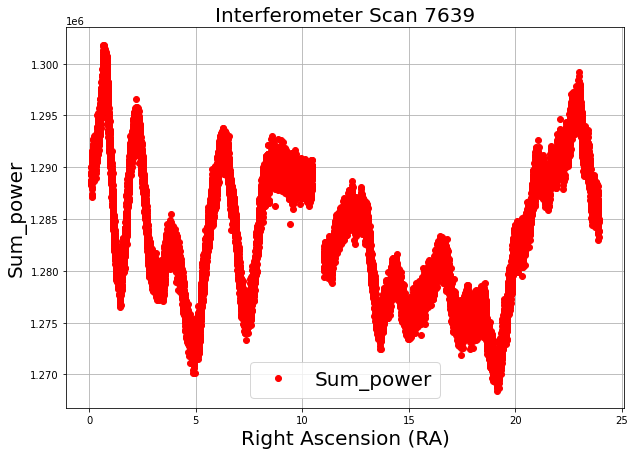

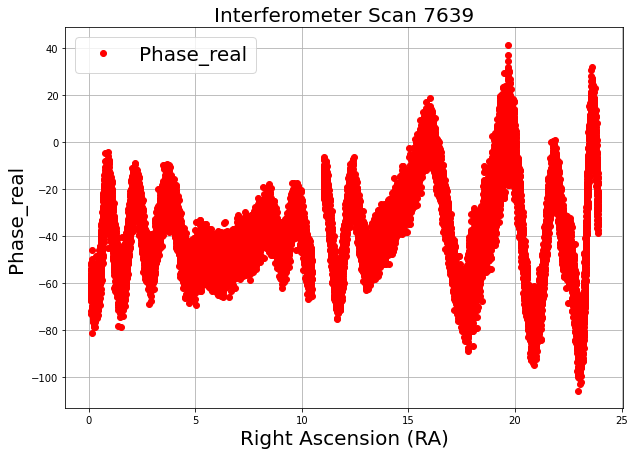

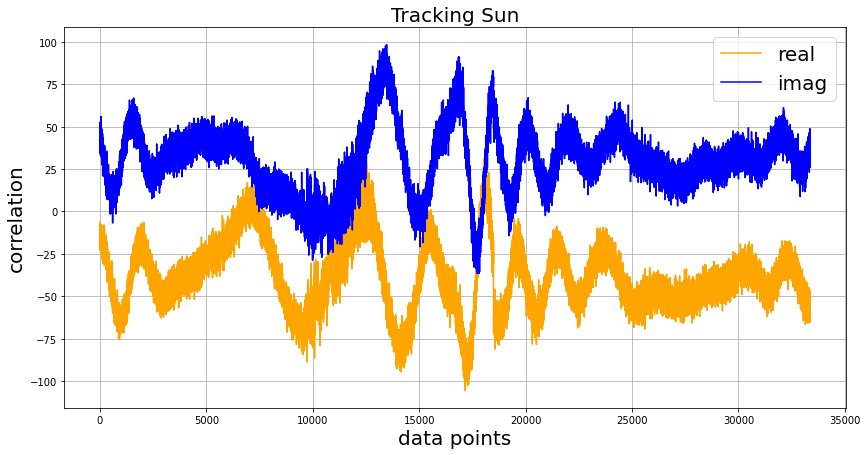

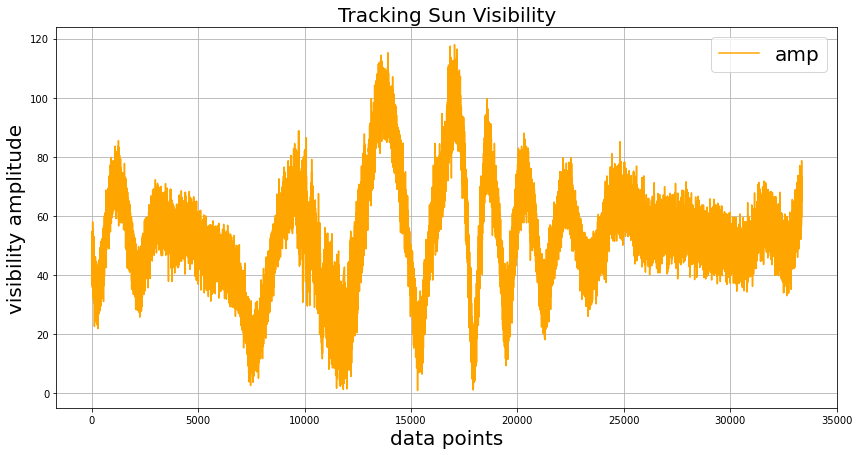

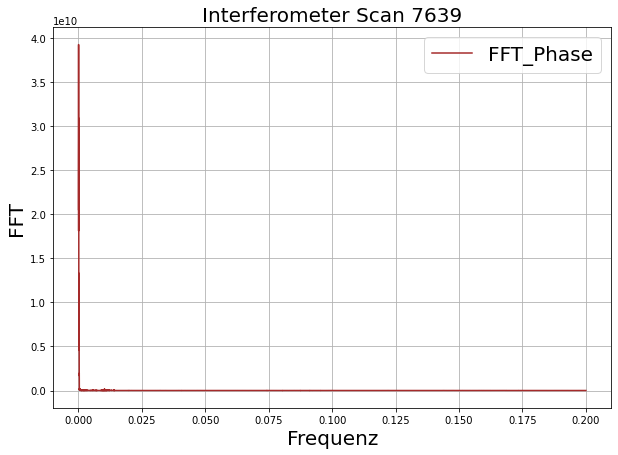

In [1]:
### Analysis of Interferometry Data L-Band
#--------------------------------------



# import packages
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.fftpack import fft, fftfreq
from scipy import signal
import os
import datetime
from datetime import datetime
#--------------------------------------

# define filename and get Scan number
filename_data = './Daten/LCORR_7639.csv'
scan_number = filename_data[-8:-4]
obj =filename_data[8:-9]
filename_info = './Daten/CAS_A_7025.inf'
info = open(filename_info)

Mess_date=info.read()[84:111]
info = open(filename_info)
IF_freq =info.read()[149:159]
info = open(filename_info)
Sampling_rate =info.read()[174:181]
info = open(filename_info)
gain0=info.read()[209:214]
info = open(filename_info)
gain1=info.read()[222:227]

#--------------------------------------

# set range of RA and resample
min_RA = 0.1
max_RA = 23.9
resample = 1
datetime=datetime.now().strftime('%y-%m-%d %H:%M:%S')
#--------------------------------------

# test if data directory exists and if file exists, if yes start analysis, else give feedback
if os.path.isdir('./Daten') == False:
    print('Im aktuellen Verzeichnis muss ein Ordner Daten existieren!')
if os.path.isfile(filename_data) == False:
    print('Die gewünschte Datei mit den Daten zur Auswertung ist nicht vorhanden!')
if os.path.isfile(filename_info) == False:
    print('Die gewünschte Datei mit den Infos zur Messung ist nicht vorhanden!')    
else:
    # create subfolder Plots to save plots of analysis
    if os.path.isdir('./Analysis_Scan'+str(scan_number)+'_'+str(obj)) == False:
        os.mkdir('./Analysis_Scan'+str(scan_number)+'_'+str(obj))
        print('Im aktuellen Verzeichnis wurde ein Unterodner Analysis_Scan'+str(scan_number)+'_'+str(obj)+' erstellt, in dem die Abbildungen der Auswertung zu finden sind!' )
    #------------------------------------- 
    file = open("./Analysis_Scan"+str(scan_number)+"_"+str(obj)+"/output.txt", "a")        
    # start analysis, write parameter into output file
    file.write('Observatorium: Astropeiler Stockert L-Band Interferometer: 1.2m und 2.3m \n')
    
    file.write('Messung vom: '+str(Mess_date)+"\n")
    file.write('Center IF Frequenz: '+str(IF_freq)+"\n")
    file.write('Sampling Rate: '+str(Sampling_rate)+"\n")
    file.write('Gain 0: '+str(gain0)+"\n")
    file.write('Gain 1: '+str(gain1)+"\n")
    file.write('Auswertung vom: '+str(datetime)+"\n")
    
    file.write('Scan-Nummer: '+str(scan_number)+"\n")
    file.write('Objektname: '+str(obj)+"\n")
    
    # read in data from .csv-file and set scan number
    data = pd.read_csv(filename_data, delimiter=' ')
    #--------------------------------------
    
    # filter data according to min_RA and max_RA (set at beginning)
    data_fil=data.loc[(data['RA'] > min_RA) & (data['RA'] < max_RA)]
    min_RA= float(round(data_fil['RA'][0:1],2))
    max_RA=float(round(data_fil['RA'][-1:len(data_fil)],2))
    file.write('min_RA: '+str(min_RA)+"\n")
    file.write('max_RA: '+str(max_RA)+"\n")
    # get time interval and sampling rate
    start=pd.to_datetime((data['Time'][0]))
    stop =pd.to_datetime((data['Time'][len(data)-1]))
    time = stop-start
    interval=(time/(len(data)-1))
    T = pd.Timedelta.total_seconds(interval)
    file.write('Abtastrate: '+str(T)+"\n")
    #--------------------------------------

    # plot power of 2 channels, the power sum and real part of phase
    # saves .png files of plots in Plots with respective scan_number

    plt.figure(figsize=(10,7))
    plt.title("Interferometer Scan "+ str(scan_number), fontsize=20)
    plt.plot(data_fil['RA'], data_fil['Power_chan_0'], marker='o',ls='None',color="red",label="Power_chan_0")
    plt.xlabel('Right Ascension (RA)',fontsize=20)
    plt.ylabel('Power_chan_0',fontsize=20)
    plt.grid()
    plt.legend(loc="best", prop={'size': 20})
    plt.savefig("./Analysis_Scan"+str(scan_number)+'_'+str(obj)+"/INT"+ str(scan_number)+"_min_RA_"+str(min_RA)+"_max_RA_"+str(max_RA)+"_resample_"+str(resample)+"_power_chan_0.png",dpi=500,bbox_inches='tight')
       
    plt.figure(figsize=(10,7))
    plt.title("Interferometer Scan "+ str(scan_number), fontsize=20)
    plt.plot(data_fil['RA'], data_fil['Power_chan_1'], marker='o',ls='None',color="red",label="Power_chan_1")
    plt.xlabel('Right Ascension (RA)',fontsize=20)
    plt.ylabel('Power_chan_1',fontsize=20)
    plt.grid()
    plt.legend(loc="best", prop={'size': 20})
    plt.savefig("./Analysis_Scan"+str(scan_number)+'_'+str(obj)+"/INT"+ str(scan_number)+"_min_RA_"+str(min_RA)+"_max_RA_"+str(max_RA)+"_resample_"+str(resample)+"_power_chan_1.png",dpi=500,bbox_inches='tight')

    plt.figure(figsize=(10,7))
    plt.title("Interferometer Scan "+ str(scan_number), fontsize=20)
    plt.plot(data_fil['RA'], data_fil['Sum_power'],marker='o',ls='None',color="red",label="Sum_power")
    plt.xlabel('Right Ascension (RA)',fontsize=20)
    plt.ylabel('Sum_power',fontsize=20)
    plt.grid()
    plt.legend(loc="best", prop={'size': 20})
    plt.savefig("./Analysis_Scan"+str(scan_number)+'_'+str(obj)+"/INT"+ str(scan_number)+"_min_RA_"+str(min_RA)+"_max_RA_"+str(max_RA)+"_resample_"+str(resample)+"_sum_power.png",dpi=500,bbox_inches='tight')

    plt.figure(figsize=(10,7))
    plt.title("Interferometer Scan "+ str(scan_number), fontsize=20)
    plt.plot(data_fil['RA'], data_fil['Phase_real'],marker='o',ls='None',color="red",label="Phase_real")
    plt.xlabel('Right Ascension (RA)',fontsize=20)
    plt.ylabel('Phase_real',fontsize=20)
    plt.grid()
    plt.legend(loc="best", prop={'size': 20})
    plt.savefig("./Analysis_Scan"+str(scan_number)+'_'+str(obj)+"/INT"+ str(scan_number)+"_min_RA_"+str(min_RA)+"_max_RA_"+str(max_RA)+"_resample_"+str(resample)+"_phase_real.png",dpi=500,bbox_inches='tight')
    #--------------------------------------

    # resampling: averaging over X data points
    

    frame_real = np.array(data_fil['Phase_real'])
    frame_real_res = signal.resample(frame_real, int(len(frame_real)/resample))

    frame_imag = np.array(data_fil['Phase_imag'])
    frame_imag_res = signal.resample(frame_imag, int(len(frame_imag)/resample))

    
    plt.figure(figsize=(14,7))
    plt.title("Tracking Sun", fontsize=20)
    plt.plot(frame_real_res, color="orange",label="real")
    plt.plot(frame_imag_res,color="blue",label="imag")
    plt.xlabel('data points',fontsize=20)
    plt.ylabel('correlation',fontsize=20)
    plt.grid()
    plt.legend(loc="best", prop={'size': 20})
    plt.savefig("./Analysis_Scan"+str(scan_number)+'_'+str(obj)+"/INT"+ str(scan_number)+"_min_RA_"+str(min_RA)+"_max_RA_"+str(max_RA)+"_resample_"+str(resample)+"_resample_phase.png",dpi=200,bbox_inches='tight')
    
    plt.figure(figsize=(14,7))
    plt.title("Tracking Sun Visibility", fontsize=20)
    plt.plot(np.sqrt(frame_real_res**2+frame_imag_res**2), color="orange",label="amp")
    plt.xlabel('data points',fontsize=20)
    plt.ylabel('visibility amplitude',fontsize=20)
    plt.grid()
    plt.legend(loc="best", prop={'size': 20})
    plt.savefig("./Analysis_Scan"+str(scan_number)+'_'+str(obj)+"/INT"+ str(scan_number)+"_min_RA_"+str(min_RA)+"_max_RA_"+str(max_RA)+"_resample_"+str(resample)+"_vis_amplitude.png",dpi=200,bbox_inches='tight')
    #--------------------------------------

    # FFT of resampled real and imaginary part of phase
    fft_real=fft(frame_real_res)
    fft_imag=fft(frame_imag_res)
    power=np.abs(fft_real)**2 + np.abs(fft_imag)**2
    N=len(power)
    file.write('Datenanzahl in power: '+str(N)+"\n")
    xf=fftfreq(N, T)

    max_in_power=(np.argmax(power[5:int(N/2)]))
    max_freq = (xf[max_in_power])/resample
    max_time = 1/max_freq
    file.write('Fringe Time: '+str(max_time)+"\n")
    file.write('Fringe Frequency: '+str(max_freq)+"\n")

    plt.figure(figsize=(10,7))
    plt.title("Interferometer Scan "+ str(scan_number), fontsize=20)
    plt.plot(xf[5:int(N/2)],power[5:int(N/2)], color="brown",label="FFT_Phase")
    plt.xlabel('Frequenz',fontsize=20)
    plt.ylabel('FFT',fontsize=20)
    plt.grid()
    plt.legend(loc="best", prop={'size': 20})
    plt.savefig("./Analysis_Scan"+str(scan_number)+'_'+str(obj)+"/INT"+ str(scan_number)+"_min_RA_"+str(min_RA)+"_max_RA_"+str(max_RA)+"_resample_"+str(resample)+"_FFT_phase.png",dpi=500,bbox_inches='tight')
    #--------------------------------------
    file.write("Es wurden folgende Plots erstellt:\n")
    file.write("INT"+ str(scan_number)+"_min_RA_"+str(min_RA)+"_max_RA_"+str(max_RA)+"_resample_"+str(resample)+"_power_chan_0.png\n")
    file.write("INT"+ str(scan_number)+"_min_RA_"+str(min_RA)+"_max_RA_"+str(max_RA)+"_resample_"+str(resample)+"_power_chan_1.png\n")
    file.write("INT"+ str(scan_number)+"_min_RA_"+str(min_RA)+"_max_RA_"+str(max_RA)+"_resample_"+str(resample)+"_sum_power.png\n")
    file.write("INT"+ str(scan_number)+"_min_RA_"+str(min_RA)+"_max_RA_"+str(max_RA)+"_resample_"+str(resample)+"_phase_real.png\n")
    file.write("INT"+ str(scan_number)+"_min_RA_"+str(min_RA)+"_max_RA_"+str(max_RA)+"_resample_"+str(resample)+"_resample_phase.png\n")
    file.write("INT"+ str(scan_number)+"_min_RA_"+str(min_RA)+"_max_RA_"+str(max_RA)+"_resample_"+str(resample)+"_FFT_phase.png\n")
    file.write("Auswertung fertig!\n")
    file.write("                 \n")
    
    print("Auswertung fertig!")
file.close()

In [2]:
import os
#os.remove("./Analysis_Scan"+str(scan_number)+"_"+str(obj)+"/output.txt")

In [3]:
time=np.array(data_fil['Time'])
#print(time)

In [4]:
def get_sec(time_str):
    '''
    input: time string in format 00:00:00
    split time string into hours(h), minutes(m) and seconds(s)
    output: converted fractional time
    '''
    h,m,s=time_str.split(':')
    
    return (float(h)*3600+float(m)*60+float(s))/3600
time_h = [get_sec(x) for x in time]
#print(time_h)

In [5]:
import ephem
from astropy.coordinates import SkyCoord
ha=np.array([])
ha_rad=np.array([])
dec=np.array([])
# define Stockert Observatory
obs=ephem.Observer()
obs.lat='50.569417'
obs.lon='6.722'
obs.elevation=435
#obs_day ='2024/7/23'
#sun specific
#for i in range(0,len(time_h)):
    #print(time[i])
#    obs.date=(''+str(obs_day)+' '+str(time_h[i])+'')
    #print(obs.date)
#    sun=ephem.Sun()
#    sun.compute(obs)
#    sun_ha=get_sec(str(sun.ha))
    # adjust hourangle when sun is towards East, so there is no jump at noon
#    if sun_ha>15: 
#        ha=np.append(ha,sun_ha-24)
#    else:
#        ha=np.append(ha,sun_ha)
#    ha_rad=np.append(ha_rad,np.radians(ha[i]*15))
    #print(sun_ha, ha[i], ha_rad[i])
#    sun_dec=sun.dec
#    dec=np.append(dec,sun_dec)




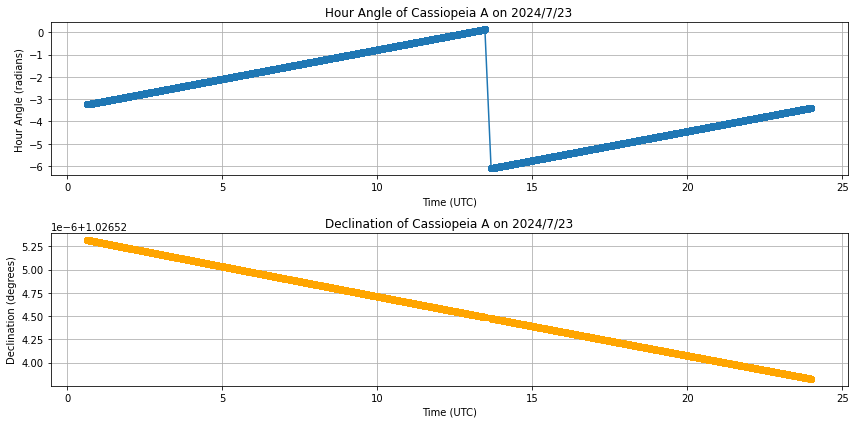

In [6]:
import ephem
import numpy as np
import matplotlib.pyplot as plt
from astropy.coordinates import SkyCoord

# Define the observer's location (Stockert Observatory)
obs = ephem.Observer()
obs.lat = '50.569417'  # Latitude
obs.lon = '6.722'      # Longitude
obs.elevation = 435     # Elevation in meters
obs_day = '2025/2/19'   # Date for observation

# Define coordinates of target ### CAS A
tar = SkyCoord(ra='23h 23m 27.5s', dec='+58d 48m 54s', frame='icrs')

# Prepare arrays to store hour angles and declinations
ha_rad = []
dec = []



# Loop through each hour of the day
for i in range(0,len(time_h)):
    obs.date=(''+str(obs_day)+' '+str(time_h[i])+'')  # Set the observer's date and time
    tar_eph = ephem.FixedBody()  # Create a fixed body for Target
    tar_eph._epoch = obs.date  # Set the epoch to the observer's date
    tar_eph._ra = tar.ra.radian  # RA in radians
    tar_eph._dec = tar.dec.radian  # Dec in radians
    tar_eph.compute(obs)  # Compute the position of Target

    # Get hour angle in degrees
    tar_ha = tar_eph.ha   # HA in radians
    

    # Append the results
    ha_rad.append(tar_eph.ha)  # Keep hour angle in radians
    dec.append(tar_eph.dec)  # Convert declination to degrees

# Convert lists to numpy arrays for easier manipulation
ha = np.array(ha_rad)
dec = np.array(dec)

# Plotting the results
plt.figure(figsize=(12, 6))
plt.subplot(2, 1, 1)
plt.plot(time_h, ha, marker='o')
plt.title('Hour Angle of Cassiopeia A on 2024/7/23')
plt.xlabel('Time (UTC)')
plt.ylabel('Hour Angle (radians)')
plt.grid()

plt.subplot(2, 1, 2)
plt.plot(time_h, dec, marker='o', color='orange')
plt.title('Declination of Cassiopeia A on 2024/7/23')
plt.xlabel('Time (UTC)')
plt.ylabel('Declination (degrees)')
plt.grid()

plt.tight_layout()
plt.show()

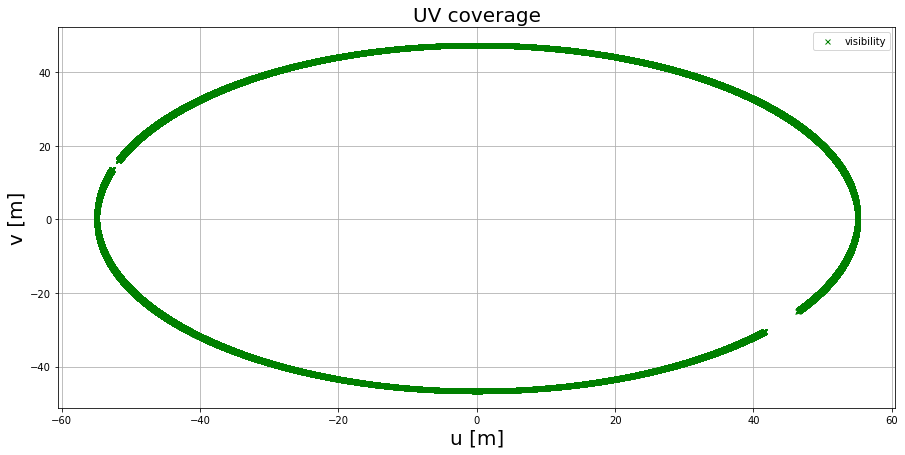

In [7]:
D=55
wavel_c=0.211
d=np.arctan2(1,D)
alpha= np.arctan2(25,49)
#print(d)
#print(alpha)
ha_plus=(90)*np.pi/180 +alpha
u_m= (D*np.cos(d)*np.sin(ha_rad-ha_plus))
v_m= (D*(np.sin(d)*np.cos(dec)-np.cos(d)*np.sin(dec)*np.cos(ha_rad-ha_plus)))
#print(u_m)

# plots of hourangle and declination of sun
plt.figure(figsize=(15,7))
plt.title("UV coverage", fontsize=20)
plt.plot((u_m), v_m,color="green",marker="x", markersize=5,ls='None',label="visibility")
plt.grid()
plt.legend(loc="best", prop={'size': 10})
plt.xlabel('u [m]',fontsize=20)
#plt.xlim(20,30)
plt.ylabel('v [m]',fontsize=20)
plt.savefig('uv_cov.png',dpi=200,bbox_inches='tight')

In [8]:
visibility= np.sqrt(data_fil['Phase_real']**2+data_fil['Phase_imag']**2)

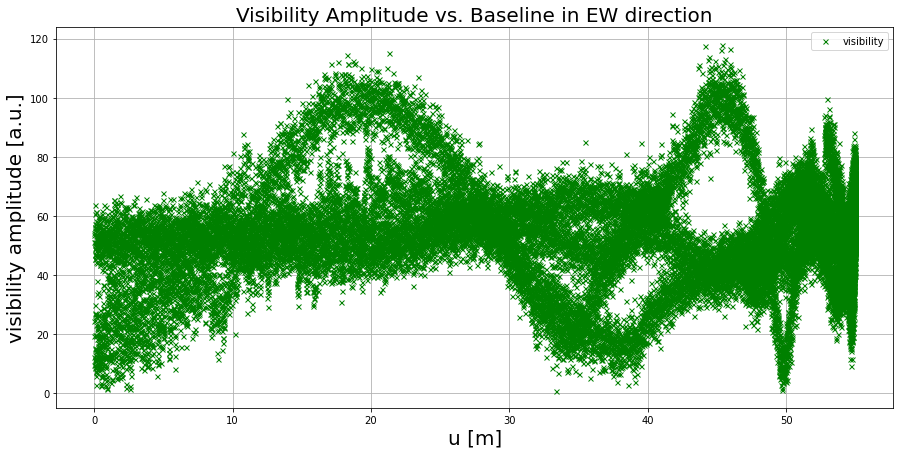

In [9]:
# plots of hourangle and declination of sun
plt.figure(figsize=(15,7))
plt.title("Visibility Amplitude vs. Baseline in EW direction", fontsize=20)
plt.plot(abs(u_m), visibility,color="green",marker="x", markersize=5,ls='None',label="visibility")
plt.grid()
plt.legend(loc="best", prop={'size': 10})
plt.xlabel('u [m]',fontsize=20)
#plt.xlim(20,30)
plt.ylabel('visibility amplitude [a.u.]',fontsize=20)
plt.savefig('Size_estimation.png',dpi=200,bbox_inches='tight')